## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import missingno

import sys

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")


from utils import process_greek, create_grid, remove_accents

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
GREEK_TO_EN = str.maketrans({
    "Α": "A", "Β": "V", "Γ": "G", "Δ": "D", "Ε": "E", "Ζ": "Z", "Η": "I", "Θ": "TH",
    "Ι": "I", "Κ": "K", "Λ": "L", "Μ": "M", "Ν": "N", "Ξ": "X", "Ο": "O", "Π": "P",
    "Ρ": "R", "Σ": "S", "Τ": "T", "Υ": "Y", "Φ": "F", "Χ": "CH", "Ψ": "PS", "Ω": "O",
    "α": "a", "β": "v", "γ": "g", "δ": "d", "ε": "e", "ζ": "z", "η": "i", "θ": "th",
    "ι": "i", "κ": "k", "λ": "l", "μ": "m", "ν": "n", "ξ": "x", "ο": "o", "π": "p",
    "ρ": "r", "σ": "s", "ς": "s", "τ": "t", "υ": "y", "φ": "f", "χ": "ch",
    "ψ": "ps", "ω": "o"
})

def greek_to_english(df: pd.DataFrame, column: str) -> pd.DataFrame:
    df[column] = (
        df[column]
        .astype(str)
        .str.translate(GREEK_TO_EN)
    )
    return df

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
NUTS0 = 'GR'
NUTS2 = 'WGreece'
NUTS2_ID = 'EL63'

In [5]:
greece_cm_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS2.shp",  encoding=enc)
greece_cm_gdf = greece_cm_gdf.loc[greece_cm_gdf['NUTS_ID'] == f'{NUTS2_ID}'].copy()

In [6]:
greece_cm_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."


In [7]:
greece_cm_gdf = greece_cm_gdf.to_crs(epsg=4326)
greece_cm_gdf.drop(columns=['NUTS_NAME'], inplace=True)
greece_cm_gdf.rename(columns={'NUTS_ID': 'div2_code',
                              'CNTR_CODE': 'div0_code',
                              'NAME_LATN': 'div2_name',
                              'CNTR_NAME': 'div0_name'}, inplace=True)

greece_cm_gdf['div0_name'] = 'ellada'
greece_cm_gdf['div1_code'] = 'EL6'
greece_cm_gdf['div1_name'] = 'kentriki ellada'
greece_cm_gdf['div2_code'] = 'EL63'

greece_cm_gdf = greece_cm_gdf[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'geometry']].copy()

In [8]:
greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].str.lower()
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].str.lower()
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].str.lower()

greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].apply(lambda x : remove_accents(x))

greece_cm_gdf.reset_index(drop=True, inplace=True)

In [9]:
greece_cm_gdf.head()

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,geometry
0,EL,ellada,EL6,kentriki ellada,EL63,dytiki ellada,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."


<Axes: >

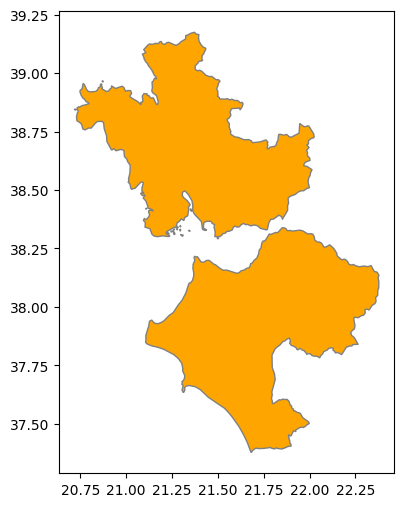

In [10]:
greece_cm_gdf.plot(facecolor="none", edgecolor='grey', figsize=(6,6), color='orange')

In [11]:
greece_cm_lv3 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS3.shp",  encoding=enc)
greece_cm_lv3 = greece_cm_lv3[greece_cm_lv3['NUTS_ID'].str.startswith(NUTS2_ID, na=False)]
greece_cm_lv3.reset_index(drop=True, inplace=True) 

In [12]:
greece_cm_lv3.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,CNTR_NAME,geometry
0,EL631,EL,Aitoloakarnania,Αιτωλοακαρνανία,2.0,3,1,Greece,"MULTIPOLYGON (((21.94600 38.78400, 21.97053 38..."
1,EL632,EL,Achaia,Αχαΐα,2.0,2,1,Greece,"POLYGON ((22.37297 38.14222, 22.37737 38.13451..."
2,EL633,EL,Ileia,Ηλεία,4.0,3,1,Greece,"POLYGON ((21.88974 37.86589, 21.87963 37.86308..."


In [13]:
greece_cm_lv3 = greece_cm_lv3.to_crs(epsg=4326)
greece_cm_lv3.drop(columns=['CNTR_CODE', 'NUTS_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'CNTR_NAME'], inplace=True)

greece_cm_lv3.rename(columns={'NUTS_ID': 'div3_code',
                              'NAME_LATN': 'div3_name'}, inplace=True)

greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].str.lower()
greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].apply(lambda x : remove_accents(x))

greece_cm_lv3['div0_name'] = 'ellada'
greece_cm_lv3['div0_code'] = 'EL'
greece_cm_lv3['div1_name'] = 'kentriki ellada'
greece_cm_lv3['div1_code'] = 'EL6'
greece_cm_lv3['div2_name'] = 'dytiki ellada'
greece_cm_lv3['div2_code'] = 'EL63'

In [14]:
greece_cm_lv3 = greece_cm_lv3[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'div3_code', 'div3_name',
                               'geometry']].copy()

In [15]:
greece_cm_lv3

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,div3_code,div3_name,geometry
0,EL,ellada,EL6,kentriki ellada,EL63,dytiki ellada,EL631,aitoloakarnania,"MULTIPOLYGON (((21.94600 38.78400, 21.97053 38..."
1,EL,ellada,EL6,kentriki ellada,EL63,dytiki ellada,EL632,achaia,"POLYGON ((22.37297 38.14222, 22.37737 38.13451..."
2,EL,ellada,EL6,kentriki ellada,EL63,dytiki ellada,EL633,ileia,"POLYGON ((21.88974 37.86589, 21.87963 37.86308..."


<Axes: >

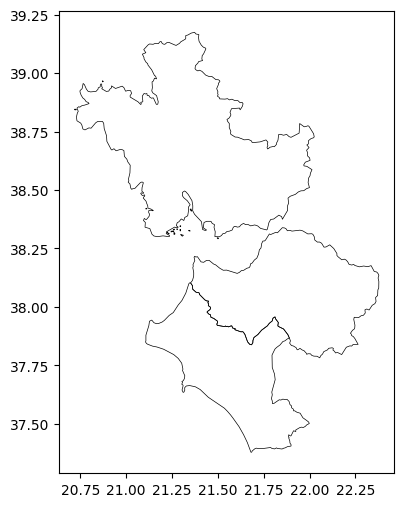

In [16]:
greece_cm_lv3.plot(facecolor="none", edgecolor='black', lw=0.5, figsize=(6,6), color='none')

In [17]:
greece_cm_lv4 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\el_lau1.shp",  encoding=enc)
process_greek(greece_cm_lv4, 'NAME')
greece_cm_lv4_buffered = greece_cm_lv4.copy()
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:3035") 
greece_cm_lv4_buffered["geometry"] = greece_cm_lv4_buffered.geometry.buffer(-800)

In [18]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered[~greece_cm_lv4_buffered.is_empty & greece_cm_lv4_buffered.is_valid]
greece_cm_lv4.shape == greece_cm_lv4_buffered.shape

False

In [19]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:4326") 
cm = greece_cm_gdf.geometry.iloc[0]
greece_cm_lv4_buffered = greece_cm_lv4_buffered[greece_cm_lv4_buffered.covered_by(cm)]
greece_cm_lv4_buffered.reset_index(drop=True, inplace=True)

<Axes: >

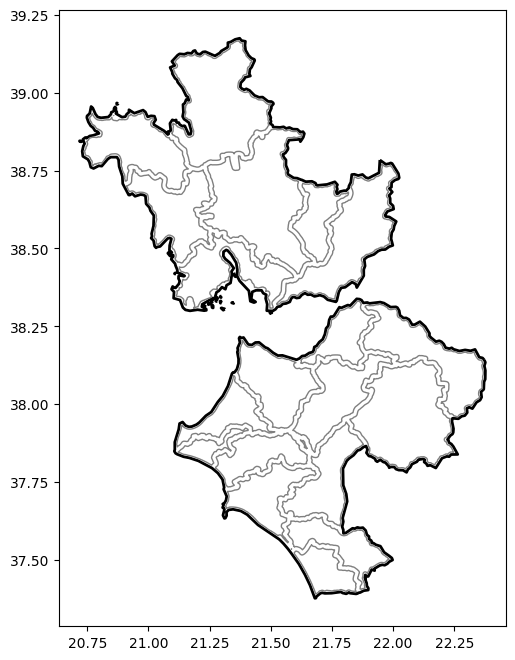

In [20]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4_buffered.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [21]:
kwd_ypes = greece_cm_lv4_buffered.KWD_YPES.to_list()

In [22]:
## This addition is due to missmatching geometries after buffering

## we are manually adding the missing KWD_YPES 9229 Dimos Elefsinas

# kwd_ypes.append('9229')

In [23]:
## Renaming div4_names names based on wrong shapefile names

## kalampakas -> metewrwn

# greece_cm_lv4.loc[greece_cm_lv4['NAME'] == 'καλαμπακας', 'NAME'] = 'μετεωρων'

In [24]:
greece_cm_lv4 = greece_cm_lv4[greece_cm_lv4['KWD_YPES'].isin(kwd_ypes)].copy()
greece_cm_lv4.rename(columns={'KWD_YPES': 'div4_code',
                             'NAME': 'div4_name'}, inplace=True)
greece_cm_lv4 = greek_to_english(greece_cm_lv4, "div4_name")
greece_cm_lv4.reset_index(drop=True, inplace=True)

In [25]:
greece_cm_lv4

,div4_name,div4_code,geometry
0,aktioy vonitsas,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
1,ilidas,9139,"POLYGON ((21.57661 37.91531, 21.57700 37.91515..."
2,agrinioy,9123,"POLYGON ((21.55728 38.88921, 21.55782 38.88862..."
3,aigialeias,9130,"POLYGON ((21.94377 38.32834, 21.94405 38.32831..."
4,amfilochias,9125,"MULTIPOLYGON (((21.15577 38.98239, 21.15567 38..."
5,andritsainas krestenon,9136,"POLYGON ((21.68810 37.64455, 21.68852 37.64419..."
6,andravidas kyllinis,9135,"MULTIPOLYGON (((21.12073 37.94136, 21.12087 37..."
7,archaias olympias,9137,"POLYGON ((21.82261 37.93943, 21.82556 37.93652..."
8,dytikis achaias,9131,"POLYGON ((21.37990 38.21236, 21.38018 38.21233..."
9,erymanthoy,9132,"POLYGON ((21.91962 38.16629, 21.92274 38.16556..."


<Axes: >

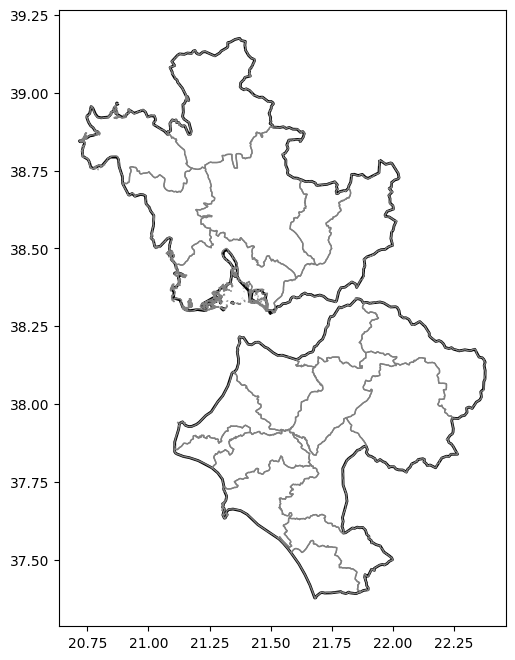

In [26]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [27]:
## GPT Code to enrich lv4 with lv3 attributes

# -------------------------------------------------------------------
# Inputs (already in memory):
#   greece_cm_lv3: polygons with div0..div3 + geometry
#   greece_cm_lv4: polygons with div4 + geometry
# Output:
#   greece_cm_lv4_enriched: lv4 with div0..div3 columns added
# -------------------------------------------------------------------

ADMIN_COLS = [
    "div0_code", "div0_name",
    "div1_code", "div1_name",
    "div2_code", "div2_name",
    "div3_code", "div3_name",
]

# 1) Ensure CRS is set and aligned
if greece_cm_lv3.crs is None or greece_cm_lv4.crs is None:
    raise ValueError(
        "One of the GeoDataFrames has no CRS set. "
        "Set it first with .set_crs(..., inplace=True) before running this."
    )

if greece_cm_lv3.crs != greece_cm_lv4.crs:
    greece_cm_lv4 = greece_cm_lv4.to_crs(greece_cm_lv3.crs)

# 2) Compute inside-points for lv4 (use representative_point to guarantee inside)
lv4 = greece_cm_lv4.copy()
crs_orig = lv4.crs

# For accurate point computations, do it in a metric CRS if current CRS is geographic
if crs_orig.is_geographic:
    # ETRS89 / LAEA Europe (meters) - safe default for Europe/Greece
    lv4_metric = lv4.to_crs(3035)
    lv4_metric["__pt"] = lv4_metric.geometry.representative_point()
    lv4["__pt"] = lv4_metric["__pt"].to_crs(crs_orig)
else:
    lv4["__pt"] = lv4.geometry.representative_point()

lv4_pts = gpd.GeoDataFrame(
    lv4[["div4_code", "div4_name", "__pt"]].copy(),
    geometry="__pt",
    crs=crs_orig,
)

# 3) Spatial join: which lv3 polygon contains the lv4 inside-point?
lv3_for_join = greece_cm_lv3[ADMIN_COLS + ["geometry"]].copy()

# If you suspect invalid geometries in lv3, uncomment:
# lv3_for_join["geometry"] = lv3_for_join.geometry.make_valid()

joined = (
    gpd.sjoin(
        lv4_pts,
        lv3_for_join,
        how="left",
        predicate="within",   # point within polygon
    )
    .drop(columns=["index_right"], errors="ignore")
)

# 4) Merge attributes back onto lv4 polygons
greece_cm_lv4_enriched = (
    greece_cm_lv4
    .merge(joined[["div4_code"] + ADMIN_COLS], on="div4_code", how="left")
)

# 5) Quick diagnostics
missing = greece_cm_lv4_enriched[ADMIN_COLS].isna().any(axis=1)
print(f"Unmatched LV4 rows (no containing LV3 polygon found): {missing.sum()} / {len(missing)}")


Unmatched LV4 rows (no containing LV3 polygon found): 0 / 19


In [28]:
greece_cm_lv4 = greece_cm_lv4_enriched[['div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'geometry']].copy()

In [29]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

In [30]:
df_grid_cm_d2 = create_grid(empty_gdf, greece_cm_gdf, col_municipal='div0_name', dimension=2)

In [31]:
df_grid_cm_d2.head()

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((20.76333 38.79680, 20.76333 38.81477...",POINT (20.752030187870567 38.80578598221707),ellada,20.75203,38.80579,2
1,"POLYGON ((20.76333 38.81477, 20.76333 38.83274...",POINT (20.752030187870567 38.823752673817296),ellada,20.75203,38.82375,2
2,"POLYGON ((20.76333 38.83274, 20.76333 38.85070...",POINT (20.752030187870567 38.84171936541751),ellada,20.75203,38.84172,2
3,"POLYGON ((20.78594 38.77884, 20.78594 38.79680...",POINT (20.77463964645095 38.78781929061687),ellada,20.77464,38.78782,2
4,"POLYGON ((20.78594 38.79680, 20.78594 38.81477...",POINT (20.77463964645095 38.80578598221707),ellada,20.77464,38.80579,2


In [32]:
df_grid_cm_d2.shape

(2567, 6)

<Axes: >

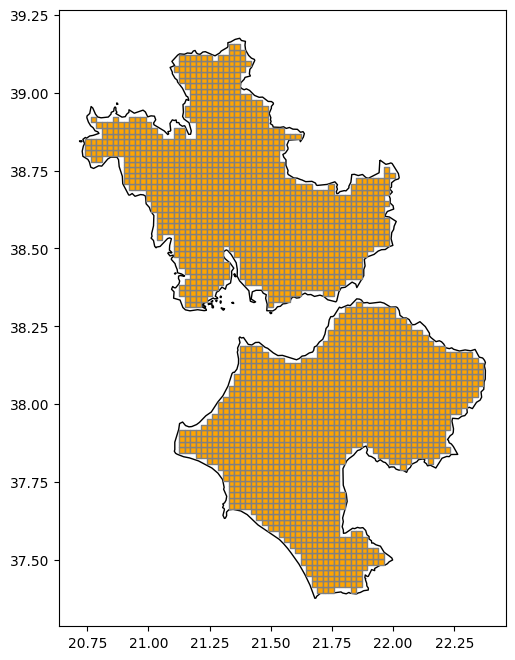

In [33]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_cm_d2.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [34]:
df_grid_cm_d2.set_geometry('centers', inplace=True)
df_grid_cm_d2.set_crs(epsg=4326, inplace=True)

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((20.76333 38.79680, 20.76333 38.81477...",POINT (20.75203 38.80579),ellada,20.75203,38.80579,2
1,"POLYGON ((20.76333 38.81477, 20.76333 38.83274...",POINT (20.75203 38.82375),ellada,20.75203,38.82375,2
2,"POLYGON ((20.76333 38.83274, 20.76333 38.85070...",POINT (20.75203 38.84172),ellada,20.75203,38.84172,2
3,"POLYGON ((20.78594 38.77884, 20.78594 38.79680...",POINT (20.77464 38.78782),ellada,20.77464,38.78782,2
4,"POLYGON ((20.78594 38.79680, 20.78594 38.81477...",POINT (20.77464 38.80579),ellada,20.77464,38.80579,2
...,...,...,...,...,...,...
2562,"POLYGON ((22.34600 38.13204, 22.34600 38.15000...",POINT (22.33469 38.14102),ellada,22.33469,38.14102,2
2563,"POLYGON ((22.36861 38.06017, 22.36861 38.07813...",POINT (22.35730 38.06915),ellada,22.35730,38.06915,2
2564,"POLYGON ((22.36861 38.07813, 22.36861 38.09610...",POINT (22.35730 38.08712),ellada,22.35730,38.08712,2
2565,"POLYGON ((22.36861 38.09610, 22.36861 38.11407...",POINT (22.35730 38.10509),ellada,22.35730,38.10509,2


In [35]:
greece_cm_grid = gpd.sjoin(df_grid_cm_d2, greece_cm_lv4, how='left', op='within')

In [36]:
greece_cm_grid.head()

,geometry,centers,div0_name_left,x,y,resolution_km,index_right,div0_name_right,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code
0,"POLYGON ((20.76333 38.79680, 20.76333 38.81477...",POINT (20.75203 38.80579),ellada,20.75203,38.80579,2,0,ellada,kentriki ellada,dytiki ellada,aitoloakarnania,aktioy vonitsas,EL,EL6,EL63,EL631,9124
1,"POLYGON ((20.76333 38.81477, 20.76333 38.83274...",POINT (20.75203 38.82375),ellada,20.75203,38.82375,2,0,ellada,kentriki ellada,dytiki ellada,aitoloakarnania,aktioy vonitsas,EL,EL6,EL63,EL631,9124
2,"POLYGON ((20.76333 38.83274, 20.76333 38.85070...",POINT (20.75203 38.84172),ellada,20.75203,38.84172,2,0,ellada,kentriki ellada,dytiki ellada,aitoloakarnania,aktioy vonitsas,EL,EL6,EL63,EL631,9124
3,"POLYGON ((20.78594 38.77884, 20.78594 38.79680...",POINT (20.77464 38.78782),ellada,20.77464,38.78782,2,0,ellada,kentriki ellada,dytiki ellada,aitoloakarnania,aktioy vonitsas,EL,EL6,EL63,EL631,9124
4,"POLYGON ((20.78594 38.79680, 20.78594 38.81477...",POINT (20.77464 38.80579),ellada,20.77464,38.80579,2,0,ellada,kentriki ellada,dytiki ellada,aitoloakarnania,aktioy vonitsas,EL,EL6,EL63,EL631,9124


In [37]:
greece_cm_grid.dropna(inplace=True)

In [38]:
final_grid = greece_cm_grid[['x', 'y', 'div0_name_right', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']].copy()
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'div0_name_right': "div0_name"}, inplace=True)
final_grid.sort_values(by=['x', 'y', 'div4_name'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

<Axes: >

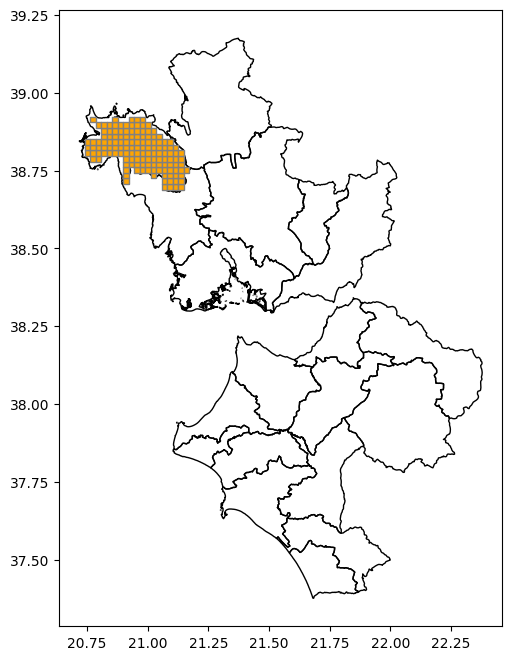

In [40]:
ax = greece_cm_lv4.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
final_grid[final_grid['div4_name'] == 'aktioy vonitsas'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [41]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of greece_cm_lv4: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (19,)
Shape of greece_cm_lv4: (19,)


In [42]:
diff = list(set(greece_cm_lv4.div4_name.unique().tolist()) - set(final_grid.div4_name.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 0
Missing GIDs are: []


In [43]:
missing_LAUs_d2 = greece_cm_lv4[greece_cm_lv4.div4_name.isin(diff)].copy()
missing_LAUs_d2.reset_index(drop=True, inplace=True)

In [44]:
missing_LAUs_d2

,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,geometry


In [45]:
missing_LAUs_d2["centers"] = missing_LAUs_d2.geometry.centroid

In [46]:
missing_LAUs_d2['resolution_km'] = 1

In [47]:
# ax = missing_LAUs_d2.plot(edgecolor='black', facecolor='none', figsize=(6, 6))
# missing_LAUs_d2['centers'].plot(ax=ax, color='red', markersize=5)

In [48]:
missing_LAUs_d2["x"] = missing_LAUs_d2["centers"].x
missing_LAUs_d2["y"] = missing_LAUs_d2["centers"].y
missing_LAUs_d2 = missing_LAUs_d2[['x', 'y', 'div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']]



In [49]:
missing_LAUs_d2.head()

,x,y,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,centers,geometry


In [50]:
final_grid = pd.concat([final_grid, missing_LAUs_d2], ignore_index=True)

In [51]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of greece_cm_lv4: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (19,)
Shape of greece_cm_lv4: (19,)


In [52]:
final_grid.sort_values(by=['div2_code', 'div3_code', 'div4_code', 'x', 'y'], inplace = True)
final_grid.rename(columns={'x': 'longitude', 'y': 'latitude'}, inplace=True)
final_grid.reset_index(drop=True, inplace=True)
final_grid.drop(columns=['centers'], inplace=True)
final_grid

,longitude,latitude,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,geometry
0,21.20422,38.60815,ellada,kentriki ellada,dytiki ellada,aitoloakarnania,agrinioy,EL,EL6,EL63,EL631,9123,2,"POLYGON ((21.21552 38.59917, 21.21552 38.61714..."
1,21.22683,38.59019,ellada,kentriki ellada,dytiki ellada,aitoloakarnania,agrinioy,EL,EL6,EL63,EL631,9123,2,"POLYGON ((21.23813 38.58120, 21.23813 38.59917..."
2,21.22683,38.60815,ellada,kentriki ellada,dytiki ellada,aitoloakarnania,agrinioy,EL,EL6,EL63,EL631,9123,2,"POLYGON ((21.23813 38.59917, 21.23813 38.61714..."
3,21.22683,38.62612,ellada,kentriki ellada,dytiki ellada,aitoloakarnania,agrinioy,EL,EL6,EL63,EL631,9123,2,"POLYGON ((21.23813 38.61714, 21.23813 38.63510..."
4,21.24944,38.57222,ellada,kentriki ellada,dytiki ellada,aitoloakarnania,agrinioy,EL,EL6,EL63,EL631,9123,2,"POLYGON ((21.26074 38.56324, 21.26074 38.58120..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2562,21.63380,37.78168,ellada,kentriki ellada,dytiki ellada,ileia,pyrgoy,EL,EL6,EL63,EL633,9141,2,"POLYGON ((21.64510 37.77270, 21.64510 37.79067..."
2563,21.65641,37.76372,ellada,kentriki ellada,dytiki ellada,ileia,pyrgoy,EL,EL6,EL63,EL633,9141,2,"POLYGON ((21.66771 37.75473, 21.66771 37.77270..."
2564,21.65641,37.78168,ellada,kentriki ellada,dytiki ellada,ileia,pyrgoy,EL,EL6,EL63,EL633,9141,2,"POLYGON ((21.66771 37.77270, 21.66771 37.79067..."
2565,21.65641,37.79965,ellada,kentriki ellada,dytiki ellada,ileia,pyrgoy,EL,EL6,EL63,EL633,9141,2,"POLYGON ((21.66771 37.79067, 21.66771 37.80863..."


In [ ]:
string_cols = final_grid.select_dtypes(include=['object', 'string']).columns

final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.map(remove_accents))
final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.str.replace(r"[,.]", "", regex=True))

In [53]:
if final_grid['div3_code'].isnull().any():
    raise ValueError("div3_code contains NULL values, need rules to handle them.")

# Create a "counter" per div3_code
final_grid['counter'] = final_grid.groupby('div3_code').cumcount() + 1

# Convert counter to hex, padded to 5 digits
final_grid['hex_counter'] = final_grid['counter'].apply(lambda x: format(x, '05X'))

# Final point_code = div3_code + hex_counter
final_grid['point_code'] = final_grid['div3_code'] + final_grid['hex_counter']

# Drop helper columns
final_grid = final_grid.drop(columns=['counter', 'hex_counter'])

In [54]:
final_grid = final_grid[['point_code', 'latitude', 'longitude', 'div0_name', 'div0_code', 'div1_name', 'div1_code', 'div2_name', 'div2_code', 'div3_name', 'div3_code', 'div4_name','div4_code', 'resolution_km', 'geometry']].copy()

<Axes: >

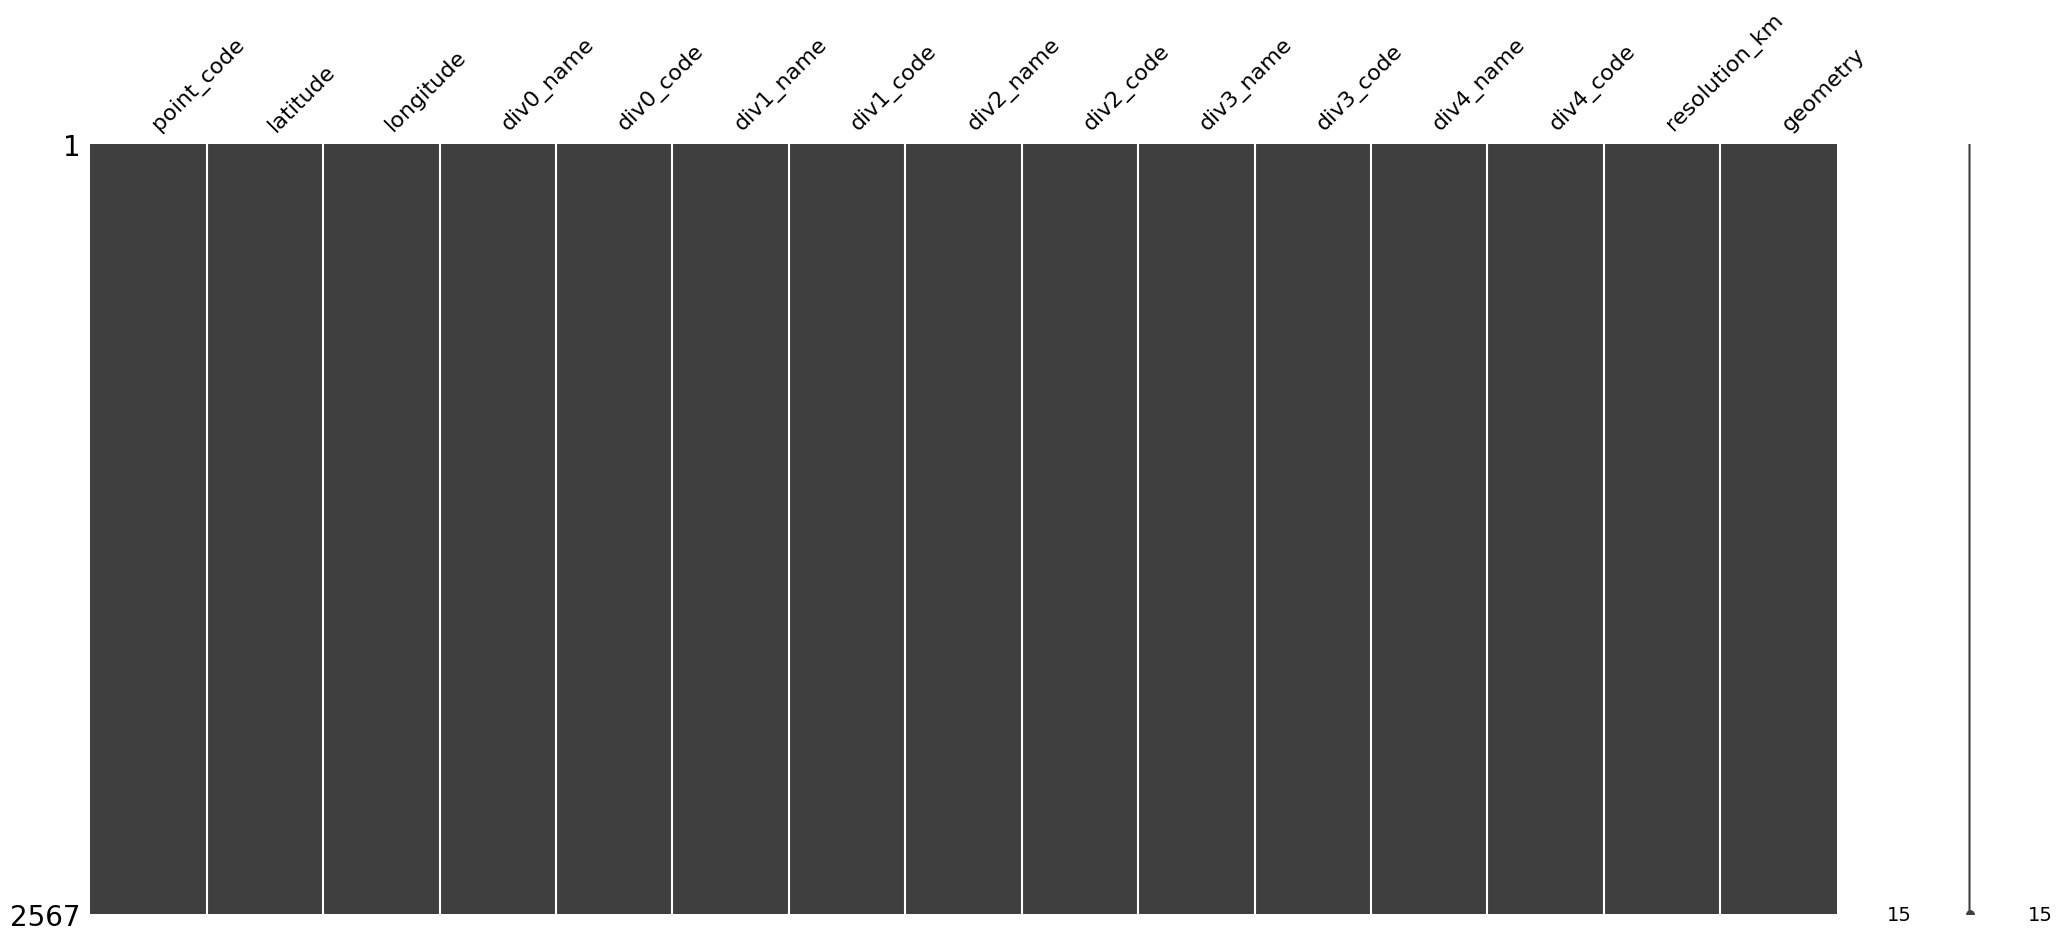

In [55]:
missingno.matrix(final_grid)

In [56]:
final_grid

,point_code,latitude,longitude,div0_name,div0_code,div1_name,div1_code,div2_name,div2_code,div3_name,div3_code,div4_name,div4_code,resolution_km,geometry
0,EL63100001,38.60815,21.20422,ellada,EL,kentriki ellada,EL6,dytiki ellada,EL63,aitoloakarnania,EL631,agrinioy,9123,2,"POLYGON ((21.21552 38.59917, 21.21552 38.61714..."
1,EL63100002,38.59019,21.22683,ellada,EL,kentriki ellada,EL6,dytiki ellada,EL63,aitoloakarnania,EL631,agrinioy,9123,2,"POLYGON ((21.23813 38.58120, 21.23813 38.59917..."
2,EL63100003,38.60815,21.22683,ellada,EL,kentriki ellada,EL6,dytiki ellada,EL63,aitoloakarnania,EL631,agrinioy,9123,2,"POLYGON ((21.23813 38.59917, 21.23813 38.61714..."
3,EL63100004,38.62612,21.22683,ellada,EL,kentriki ellada,EL6,dytiki ellada,EL63,aitoloakarnania,EL631,agrinioy,9123,2,"POLYGON ((21.23813 38.61714, 21.23813 38.63510..."
4,EL63100005,38.57222,21.24944,ellada,EL,kentriki ellada,EL6,dytiki ellada,EL63,aitoloakarnania,EL631,agrinioy,9123,2,"POLYGON ((21.26074 38.56324, 21.26074 38.58120..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2562,EL63300247,37.78168,21.63380,ellada,EL,kentriki ellada,EL6,dytiki ellada,EL63,ileia,EL633,pyrgoy,9141,2,"POLYGON ((21.64510 37.77270, 21.64510 37.79067..."
2563,EL63300248,37.76372,21.65641,ellada,EL,kentriki ellada,EL6,dytiki ellada,EL63,ileia,EL633,pyrgoy,9141,2,"POLYGON ((21.66771 37.75473, 21.66771 37.77270..."
2564,EL63300249,37.78168,21.65641,ellada,EL,kentriki ellada,EL6,dytiki ellada,EL63,ileia,EL633,pyrgoy,9141,2,"POLYGON ((21.66771 37.77270, 21.66771 37.79067..."
2565,EL6330024A,37.79965,21.65641,ellada,EL,kentriki ellada,EL6,dytiki ellada,EL63,ileia,EL633,pyrgoy,9141,2,"POLYGON ((21.66771 37.79067, 21.66771 37.80863..."


In [57]:
final_grid.drop(columns='geometry').to_csv(f'../../data/{NUTS2}/GR_{NUTS2}_Grid_DB.csv', encoding=enc, index = False)
# final_grid.to_file(f'../data/CM_Nord_Grid.shp', encoding = 'utf-8')